In [1]:
import pandas as pd

df = pd.read_csv("daily_residential.csv")

df['date'] = pd.to_datetime(df['date'])

df = df.sort_values('date')

print(df.head())

FileNotFoundError: [Errno 2] No such file or directory: 'daily_residential.csv'

In [2]:
zone_data = df.groupby(['date','zone'])['total_energy'].sum().reset_index()

In [3]:
zone = 'AEP'

data = zone_data[zone_data['zone']==zone].copy()

data = data.set_index('date')

In [4]:
train_size = int(len(data)*0.8)

train = data[:train_size]
test = data[train_size:]

In [5]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train['total_energy'], order=(2,1,2))
model_fit = model.fit()

forecast = model_fit.forecast(steps=len(test))

c:\Users\TU39\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\TU39\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\TU39\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\TU39\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [6]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(test['total_energy'], forecast)

print("ARIMA MAE:",mae)

ARIMA MAE: 66424.90936314048


In [7]:
from prophet import Prophet

prophet_df = data.reset_index()[['date','total_energy']]
prophet_df.columns = ['ds','y']

train_p = prophet_df[:train_size]
test_p = prophet_df[train_size:]

model = Prophet()

model.fit(train_p)

future = model.make_future_dataframe(periods=len(test_p))

forecast = model.predict(future)

pred = forecast['yhat'][-len(test_p):]

19:07:03 - cmdstanpy - INFO - Chain [1] start processing
19:07:04 - cmdstanpy - INFO - Chain [1] done processing


In [8]:
import numpy as np
import matplotlib.pyplot as plt

In [9]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

arima_model = ARIMA(train['total_energy'], order=(2,1,2))
arima_fit = arima_model.fit()

arima_pred = arima_fit.forecast(steps=len(test))

mae_arima = mean_absolute_error(test['total_energy'], arima_pred)
rmse_arima = np.sqrt(mean_squared_error(test['total_energy'], arima_pred))

c:\Users\TU39\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\TU39\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\TU39\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\TU39\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


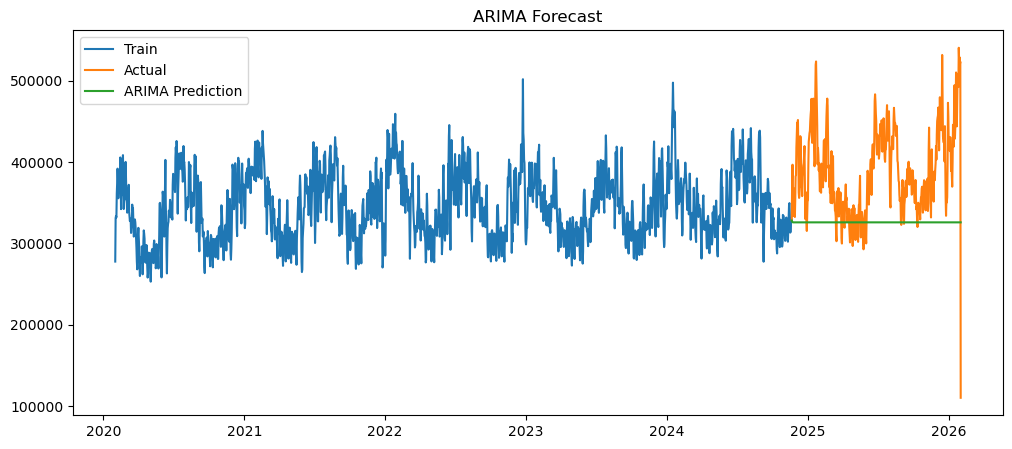

In [10]:
plt.figure(figsize=(12,5))

plt.plot(train.index, train['total_energy'], label="Train")
plt.plot(test.index, test['total_energy'], label="Actual")
plt.plot(test.index, arima_pred, label="ARIMA Prediction")

plt.title("ARIMA Forecast")
plt.legend()
plt.show()

In [11]:
from prophet import Prophet

prophet_df = data.reset_index()[['date','total_energy']]
prophet_df.columns = ['ds','y']

train_p = prophet_df[:train_size]
test_p = prophet_df[train_size:]

model = Prophet()
model.fit(train_p)

future = model.make_future_dataframe(periods=len(test_p))

forecast = model.predict(future)

prophet_pred = forecast['yhat'][-len(test_p):].values

19:07:05 - cmdstanpy - INFO - Chain [1] start processing
19:07:06 - cmdstanpy - INFO - Chain [1] done processing


In [12]:
mae_prophet = mean_absolute_error(test['total_energy'], prophet_pred)
rmse_prophet = np.sqrt(mean_squared_error(test['total_energy'], prophet_pred))

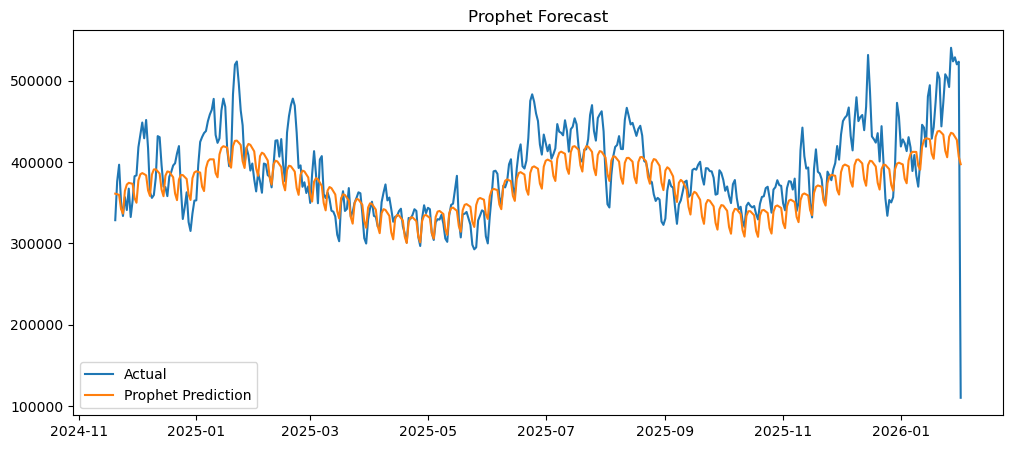

In [13]:
plt.figure(figsize=(12,5))

plt.plot(test.index, test['total_energy'], label="Actual")
plt.plot(test.index, prophet_pred, label="Prophet Prediction")

plt.title("Prophet Forecast")
plt.legend()
plt.show()

In [14]:
data_ml = data.copy()
data_ml.drop('zone',axis=1,inplace=True)
for lag in range(1,8):
    data_ml[f'lag_{lag}'] = data_ml['total_energy'].shift(lag)

data_ml.dropna(inplace=True)

X = data_ml.drop('total_energy',axis=1)
y = data_ml['total_energy']

train_size = int(len(X)*0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [15]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, rf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))

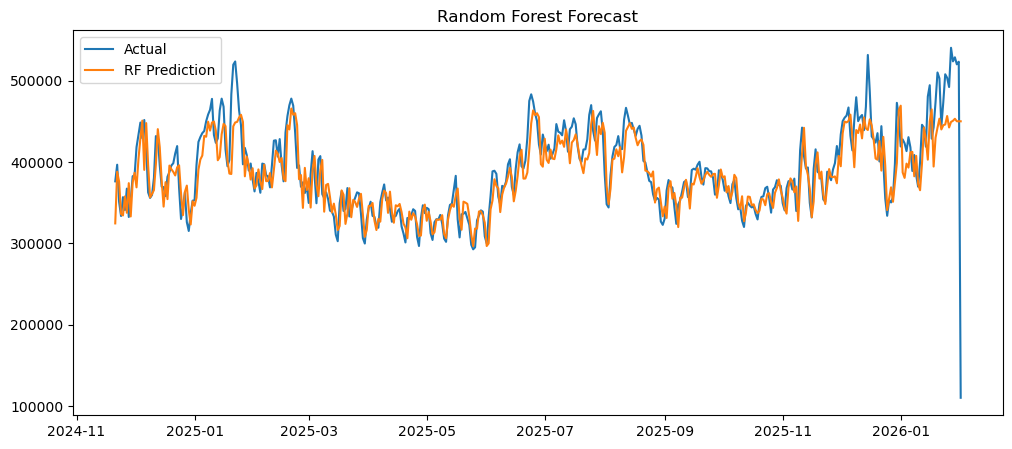

In [16]:
plt.figure(figsize=(12,5))

plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, rf_pred, label="RF Prediction")

plt.title("Random Forest Forecast")
plt.legend()
plt.show()

In [17]:
from xgboost import XGBRegressor

xgb = XGBRegressor()

xgb.fit(X_train,y_train)

xgb_pred = xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, xgb_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))

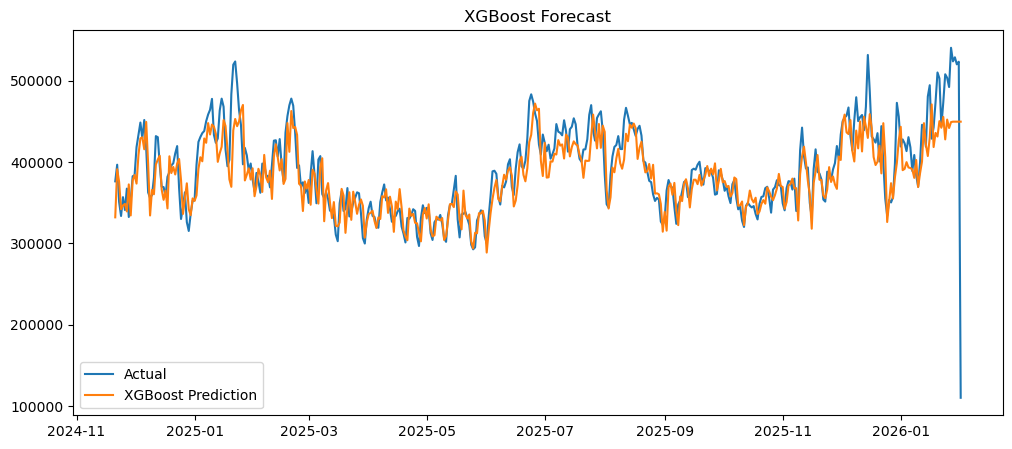

In [18]:
plt.figure(figsize=(12,5))

plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, xgb_pred, label="XGBoost Prediction")

plt.title("XGBoost Forecast")
plt.legend()
plt.show()

In [19]:
results = pd.DataFrame({
    "Model":["ARIMA","Prophet","RandomForest","XGBoost"],
    "MAE":[mae_arima, mae_prophet, mae_rf, mae_xgb],
    "RMSE":[rmse_arima, rmse_prophet, rmse_rf, rmse_xgb]
})

print(results)

          Model           MAE          RMSE
0         ARIMA  66424.909363  82103.076918
1       Prophet  29957.676125  39679.577697
2  RandomForest  19957.765069  30277.823524
3       XGBoost  20785.183355  31498.969442


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [21]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data[['total_energy']])

In [22]:
sequence_length = 30

X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    
    X.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i])

X = np.array(X)
y = np.array(y)

In [23]:
print(X.shape)

(2163, 30, 1)


In [24]:
train_size = int(len(X)*0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [26]:
lstm_model = Sequential()

lstm_model.add(LSTM(64, return_sequences=False, input_shape=(30,1)))
lstm_model.add(Dense(1))

lstm_model.compile(optimizer='adam', loss='mse')

c:\Users\TU39\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [27]:
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0351 - val_loss: 0.0054
Epoch 2/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0044 - val_loss: 0.0051
Epoch 3/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0043 - val_loss: 0.0051
Epoch 4/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0043 - val_loss: 0.0049
Epoch 5/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0042 - val_loss: 0.0049
Epoch 6/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0042 - val_loss: 0.0048
Epoch 7/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0041 - val_loss: 0.0048
Epoch 8/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0041 - val_loss: 0.0048
Epoch 9/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0040 - val_loss: 0.0048
Epoch 10/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0040 - val_loss: 0.0047
Epoch 11/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0041 - val_loss: 0.0045
Epoch 12/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0039 

In [28]:
lstm_pred = lstm_model.predict(X_test)

lstm_pred = scaler.inverse_transform(lstm_pred)
y_test_inv = scaler.inverse_transform(y_test)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


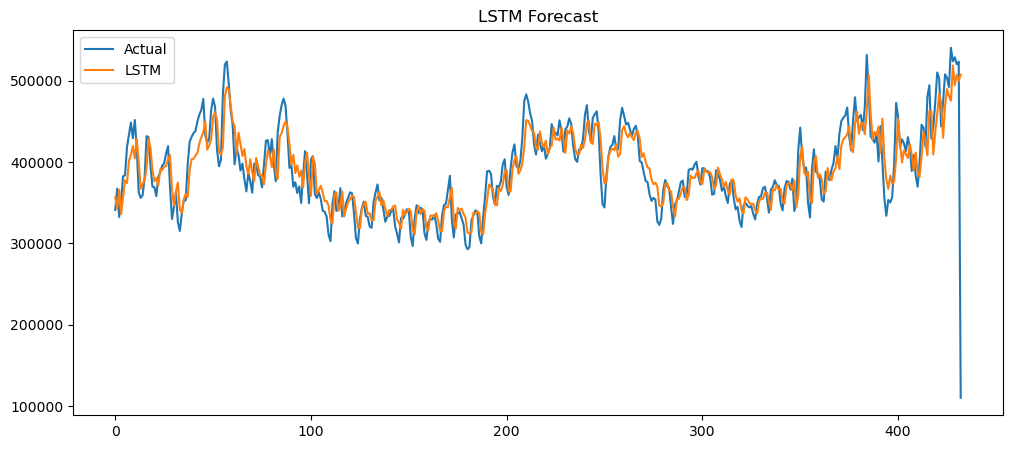

In [29]:
plt.figure(figsize=(12,5))

plt.plot(y_test_inv, label="Actual")
plt.plot(lstm_pred, label="LSTM")

plt.title("LSTM Forecast")
plt.legend()
plt.show()

In [30]:
from tensorflow.keras.layers import GRU

In [31]:
gru_model = Sequential()

gru_model.add(GRU(64, input_shape=(30,1)))
gru_model.add(Dense(1))

gru_model.compile(optimizer='adam', loss='mse')

gru_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/30


c:\Users\TU39\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0620 - val_loss: 0.0080
Epoch 2/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0048 - val_loss: 0.0050
Epoch 3/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0044 - val_loss: 0.0044
Epoch 4/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0041 - val_loss: 0.0043
Epoch 5/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0039 - val_loss: 0.0039
Epoch 6/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0036 - val_loss: 0.0036
Epoch 7/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0035 - val_loss: 0.0035
Epoch 8/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0033 - val_loss: 0.0033
Epoch 9/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0032 - val_loss: 0.0032
Epoch 10/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0030 - val_loss: 0.0034
Epoch 11/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0030 - val_loss: 0.0030
Epoch 12/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0029 - val_l

In [32]:
gru_pred = gru_model.predict(X_test)

gru_pred = scaler.inverse_transform(gru_pred)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


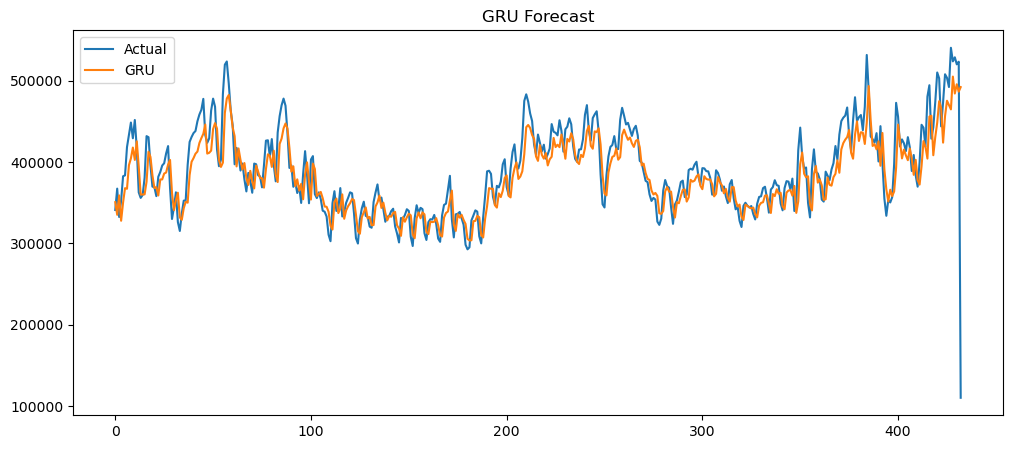

In [33]:
plt.figure(figsize=(12,5))

plt.plot(y_test_inv, label="Actual")
plt.plot(gru_pred, label="GRU")

plt.title("GRU Forecast")
plt.legend()
plt.show()

In [34]:
from tensorflow.keras.layers import Bidirectional

In [35]:
bilstm_model = Sequential()

bilstm_model.add(Bidirectional(LSTM(64), input_shape=(30,1)))
bilstm_model.add(Dense(1))

bilstm_model.compile(optimizer='adam', loss='mse')

bilstm_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/30


c:\Users\TU39\anaconda3\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0242 - val_loss: 0.0055
Epoch 2/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0050 - val_loss: 0.0053
Epoch 3/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0048 - val_loss: 0.0054
Epoch 4/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0047 - val_loss: 0.0051
Epoch 5/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0046 - val_loss: 0.0049
Epoch 6/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0044 - val_loss: 0.0049
Epoch 7/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0043 - val_loss: 0.0048
Epoch 8/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0042 - val_loss: 0.0046
Epoch 9/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0043 - val_loss: 0.0046
Epoch 10/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0043 - val_loss: 0.0045
Epoch 11/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0040 - val_loss: 0.0044
Epoch 12/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0040 - val_l

In [36]:
bilstm_pred = bilstm_model.predict(X_test)

bilstm_pred = scaler.inverse_transform(bilstm_pred)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step


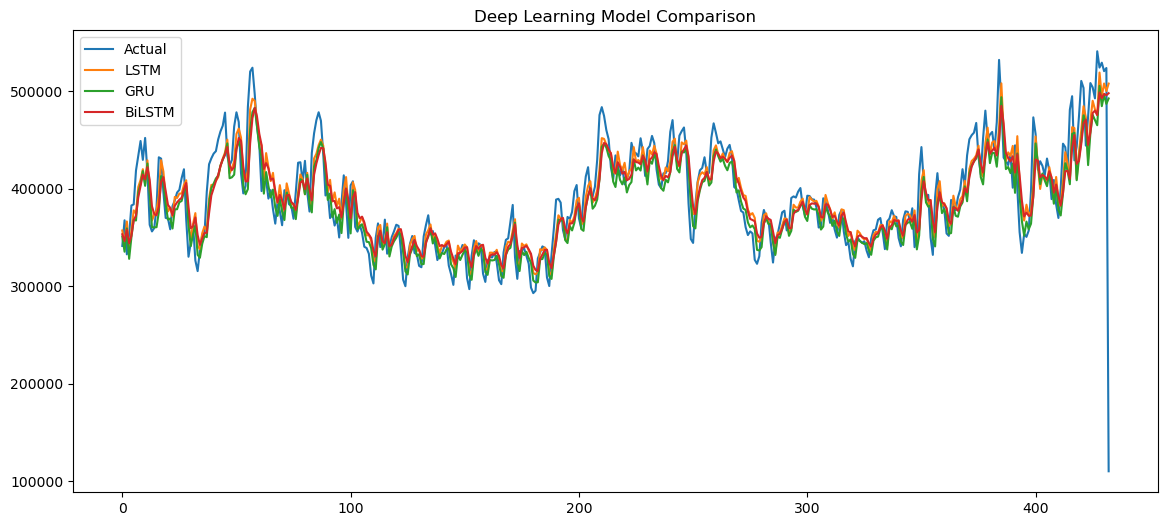

In [37]:
plt.figure(figsize=(14,6))

plt.plot(y_test_inv, label="Actual")

plt.plot(lstm_pred, label="LSTM")
plt.plot(gru_pred, label="GRU")
plt.plot(bilstm_pred, label="BiLSTM")

plt.title("Deep Learning Model Comparison")

plt.legend()

plt.show()

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(true, pred):
    
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    
    return mae, rmse

mae_lstm, rmse_lstm = evaluate(y_test_inv, lstm_pred)
mae_gru, rmse_gru = evaluate(y_test_inv, gru_pred)
mae_bilstm, rmse_bilstm = evaluate(y_test_inv, bilstm_pred)

print("LSTM:", mae_lstm, rmse_lstm)
print("GRU:", mae_gru, rmse_gru)
print("BiLSTM:", mae_bilstm, rmse_bilstm)

LSTM: 18749.41350750578 29512.384319154906
GRU: 19759.532054272513 30322.88601851817
BiLSTM: 20650.959715935336 31122.427162579712


In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D,
    Bidirectional, LSTM,
    Dense, Dropout,
    Attention, GlobalAveragePooling1D
)

In [40]:
df = pd.read_csv("daily_residential.csv")

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

zone_data = df.groupby(['date','zone'])['total_energy'].sum().reset_index()

zone = "AEP"
data = zone_data[zone_data['zone']==zone]

data = data.set_index('date')

In [41]:
scaler = MinMaxScaler()

scaled = scaler.fit_transform(data[['total_energy']])

In [42]:
seq_len = 30

X = []
y = []

for i in range(seq_len, len(scaled)):
    
    X.append(scaled[i-seq_len:i])
    y.append(scaled[i])

X = np.array(X)
y = np.array(y)

In [43]:
train_size = int(len(X)*0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [44]:
input_layer = Input(shape=(30,1))

# CNN
x = Conv1D(filters=64, kernel_size=3, activation='relu')(input_layer)
x = MaxPooling1D(pool_size=2)(x)

# BiLSTM
x = Bidirectional(LSTM(64, return_sequences=True))(x)

# Attention
attention = Attention()([x,x])

x = GlobalAveragePooling1D()(attention)

x = Dense(32, activation='relu')(x)
x = Dropout(0.2)(x)

output = Dense(1)(x)

model = Model(inputs=input_layer, outputs=output)

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 30, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 28, 64)    │        256 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 14, 64)    │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 14, 128)   │     66,048 │ max_pooling1d[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 14, 128)   │          0 │ bidirectional_1[… │
│ (Attention)         │                   │            │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ attention[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      4,128 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1)         │         33 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 70,465 (275.25 KB)

 Trainable params: 70,465 (275.25 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
history = model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/40


44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0300 - val_loss: 0.0093
Epoch 2/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0118 - val_loss: 0.0064
Epoch 3/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0110 - val_loss: 0.0062
Epoch 4/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0105 - val_loss: 0.0067
Epoch 5/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0110 - val_loss: 0.0064
Epoch 6/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0104 - val_loss: 0.0065
Epoch 7/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0098 - val_loss: 0.0068
Epoch 8/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0102 - val_loss: 0.0060
Epoch 9/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0100 - val_loss: 0.0077
Epoch 10/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0099 - val_loss: 0.0085
Epoch 11/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0103 - val_loss: 0.0060
Epoch 12/40
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0091 - val_lo

In [46]:
pred = model.predict(X_test)

pred = scaler.inverse_transform(pred)
y_test_inv = scaler.inverse_transform(y_test)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step


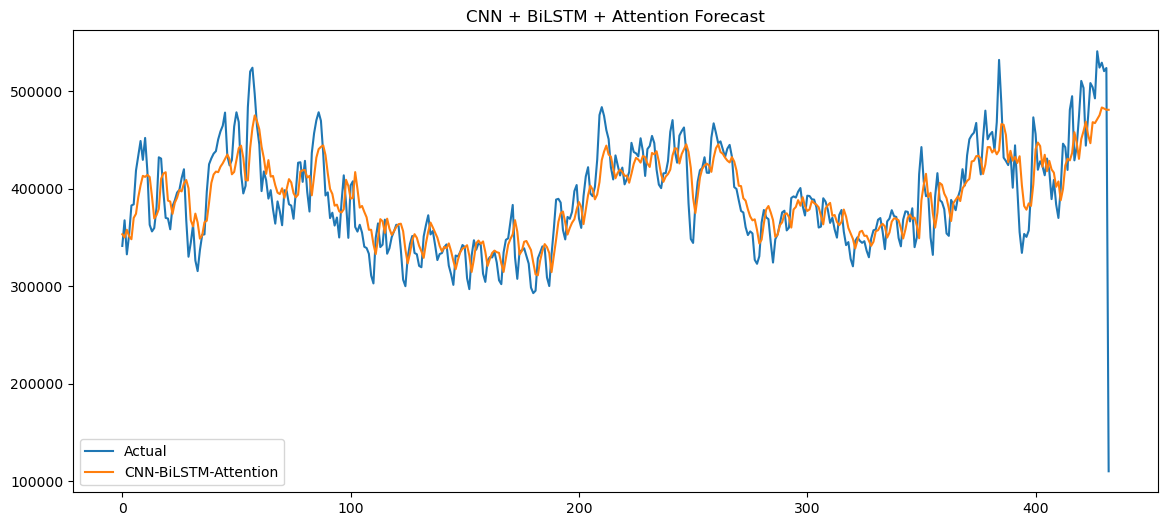

In [47]:
plt.figure(figsize=(14,6))

plt.plot(y_test_inv, label="Actual")
plt.plot(pred, label="CNN-BiLSTM-Attention")

plt.title("CNN + BiLSTM + Attention Forecast")
plt.legend()

plt.show()

In [48]:
mae = mean_absolute_error(y_test_inv, pred)

rmse = np.sqrt(mean_squared_error(y_test_inv, pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 22285.711494803694
RMSE: 32339.329669606


In [1]:
import glob

folder_path = "Commercial_data" # Example: r'C:/Users/YourUser/Desktop/data'
# Use a pattern to match all files (e.g., "*.csv" for CSV files, or "*" for all files)
file_list = glob.glob(folder_path + "/*") 

print(file_list)


['Commercial_data\\Data_Commercial_AP.csv', 'Commercial_data\\Data_Commercial_BC.csv', 'Commercial_data\\Data_Commercial_CE.csv', 'Commercial_data\\Data_Commercial_DAY.csv', 'Commercial_data\\Data_Commercial_DEOK.csv', 'Commercial_data\\Data_Commercial_DOM.csv', 'Commercial_data\\Data_Commercial_DUQ.csv', 'Commercial_data\\Data_Commercial_EKPC.csv', 'Commercial_data\\Data_Commercial_JC.csv', 'Commercial_data\\Data_Commercial_ME.csv', 'Commercial_data\\Data_Commercial_OVEC.csv', 'Commercial_data\\Data_Commercial_PE.csv', 'Commercial_data\\Data_Commercial_PN.csv', 'Commercial_data\\Data_Commercial_PS.csv', 'Commercial_data\\Data_Commercial_RECO.csv']


In [2]:
import glob

folder_path = "Residential_data" # Example: r'C:/Users/YourUser/Desktop/data'
# Use a pattern to match all files (e.g., "*.csv" for CSV files, or "*" for all files)
file_list = glob.glob(folder_path + "/*") 

print(file_list)

['Residential_data\\Data_Residential_AE.csv', 'Residential_data\\Data_Residential_AEP.csv', 'Residential_data\\Data_Residential_ATSI.csv', 'Residential_data\\Data_Residential_DPL.csv', 'Residential_data\\Data_Residential_PEP.csv', 'Residential_data\\Data_Residential_PL.csv']


In [51]:
import glob

folder_path = "Industrial_data" # Example: r'C:/Users/YourUser/Desktop/data'
# Use a pattern to match all files (e.g., "*.csv" for CSV files, or "*" for all files)
file_list = glob.glob(folder_path + "/*") 

print(file_list)

['Industrial_data\\Data_Industrial_RTO.csv']


In [52]:
import pandas as pd
import numpy as np
import glob
import warnings

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    LSTM, GRU, Dense, Bidirectional,
    Conv1D, MaxPooling1D, Dropout,
    Attention, Input, GlobalAveragePooling1D
)

warnings.filterwarnings("ignore")

In [53]:
res_files = glob.glob("Residential_data/*.csv")
com_files = glob.glob("Commercial_data/*.csv")
ind_files = glob.glob("Industrial_data/*.csv")

all_files = res_files + com_files + ind_files

print("Total datasets:", len(all_files))

Total datasets: 43
